# Store Sales Forecasting - 01 Data Understanding and Preparation

This notebook prepares the store sales dataset for a later supervised learning / PyTorch forecasting model.

## 1. Imports and Settings

IMPORTANT!! `USE_SAMPLE` IS TO SET "FALSE" TO TRAIN THE MODEL WITH THE FULL DATASET AVAILABLE. THIS IS JUST NOT TO GET CRAZY WHILE TESTING
(this is to downscale the sample dinamically if you pc is limited. DO NOT USE FOR FINAL REPORT. Output produced by the future notebooks will be limited)

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

DATA_DIR = Path("Data")
OUTPUT_DIR = Path("outputs/prepared_notebook")

USE_SAMPLE = False #IMPORTANT!! TO SET "FALSE" TO TRAIN THE MODEL WITH THE FULL DATASET AVAILABLE.
SAMPLE_STORES = 100
MIN_DATE = "2014-01-01"

# Final validation period: the last 6 weeks of training data.
VALIDATION_DAYS = 42
RANDOM_STATE = 42

## 2. Load the Raw Data

In [2]:
train = pd.read_csv(
    DATA_DIR / "train.csv",
    parse_dates=["Date"],
    dtype={"StateHoliday": "string"},
    low_memory=False,
)

test = pd.read_csv(
    DATA_DIR / "test.csv",
    parse_dates=["Date"],
    dtype={"StateHoliday": "string"},
    low_memory=False,
)

store = pd.read_csv(DATA_DIR / "store.csv", low_memory=False)

RAW_TRAIN_SHAPE = train.shape
RAW_TEST_SHAPE = test.shape
RAW_STORE_SHAPE = store.shape

print("train shape:", train.shape)
print("test shape:", test.shape)
print("store shape:", store.shape)

train shape: (1017209, 9)
test shape: (41088, 8)
store shape: (1115, 10)


## 3. Data Understanding

We inspect the columns, date ranges, missing values, and basic target distribution.

In [3]:
def summarize_dataframe(df, name):
    print(f"\n{name}")
    print("-" * len(name))
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    
    if "Date" in df.columns:
        print("date range:", df["Date"].min().date(), "to", df["Date"].max().date())
    
    if "Store" in df.columns:
        print("number of stores:", df["Store"].nunique())
    
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print("missing values:")
    display(missing.to_frame("missing_rows"))
    
    display(df.head())


summarize_dataframe(train, "train.csv")
summarize_dataframe(test, "test.csv")
summarize_dataframe(store, "store.csv")


train.csv
---------
shape: (1017209, 9)
columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
date range: 2013-01-01 to 2015-07-31
number of stores: 1115
missing values:


,missing_rows


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1



test.csv
--------
shape: (41088, 8)
columns: ['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
date range: 2015-08-01 to 2015-09-17
number of stores: 856
missing values:


,missing_rows
Open,11


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0



store.csv
---------
shape: (1115, 10)
columns: ['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
number of stores: 1115
missing values:


,missing_rows
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
CompetitionDistance,3


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
print("Sales summary:")
display(train["Sales"].describe().to_frame())

print("Rows with zero sales:", int((train["Sales"] == 0).sum()))
print("Rows where store is closed:", int((train["Open"] == 0).sum()))

print("Average sales by Open flag:")
display(train.groupby("Open")["Sales"].agg(["count", "mean", "median", "min", "max"]))

print("Average sales by promotion flag:")
display(train.groupby("Promo")["Sales"].agg(["count", "mean", "median"]))

Sales summary:


,Sales
count,1.017209e+06
mean,5.773819e+03
std,3.849926e+03
min,0.000000e+00
25%,3.727000e+03
50%,5.744000e+03
75%,7.856000e+03
max,4.155100e+04


Rows with zero sales: 172871
Rows where store is closed: 172817
Average sales by Open flag:


,count,mean,median,min,max
Open,,,,,
0,172817,0.000000,0.0,0,0
1,844392,6955.514291,6369.0,0,41551


Average sales by promotion flag:


,count,mean,median
Promo,,,
0,629129,4406.050805,4622.0
1,388080,7991.152046,7553.0


## 4. Optional Down-Sampling

BASED ON THE USE_SAMPLE SETTING ABOVE (see cell block 1)

The full dataset has more than one million training rows. For fast experimentation, we can keep only a subset of stores and/or recent dates. This is useful while developing the project. Later, we can disable sampling and rerun everything.

In [5]:
if USE_SAMPLE:
    rng = np.random.default_rng(RANDOM_STATE)
    selected_stores = sorted(
        rng.choice(sorted(train["Store"].unique()), size=SAMPLE_STORES, replace=False)
    )
    
    train = train[train["Store"].isin(selected_stores)].copy()
    test = test[test["Store"].isin(selected_stores)].copy()
    train = train[train["Date"] >= pd.Timestamp(MIN_DATE)].copy()
    
    print(f"Using a sample of {len(selected_stores)} stores from {MIN_DATE} onward.")
else:
    selected_stores = None
    print("Using the full dataset.")

print("train shape after sampling:", train.shape)
print("test shape after sampling:", test.shape)

Using the full dataset.
train shape after sampling: (1017209, 9)
test shape after sampling: (41088, 8)


## 5. Merge Store Metadata

`store.csv` contains information such as store type, assortment, competition distance, and long-running promotions. We merge this information into every train and test row.

In [6]:
train = train.merge(store, on="Store", how="left", validate="many_to_one")
test = test.merge(store, on="Store", how="left", validate="many_to_one")

print("train shape after merge:", train.shape)
print("test shape after merge:", test.shape)

if train["StoreType"].isna().any() or test["StoreType"].isna().any():
    raise ValueError("Some stores do not have metadata in store.csv")

train shape after merge: (1017209, 18)
test shape after merge: (41088, 17)


## 6. Clean Missing Values

Cleaning rules used here:

- Missing `Open` in the test set is filled with `1`, because most stores are open unless explicitly marked closed. They have data associated that would not make sence if the store were closed.
- Missing `CompetitionDistance` is filled with the median distance. This might be problematic since time series forecast models do worst if data is redundant
- Missing competition and Promo2 date parts are filled with `0`, meaning "not known / not active".
- Missing `PromoInterval` is filled with an empty string.
- `StateHoliday` is normalized because the raw files can mix string and numeric-looking values.

In [7]:
def clean_dataframe(df, competition_distance_fill):
    df = df.copy()
    
    df["StateHoliday"] = (
        df["StateHoliday"]
        .astype("string")
        .fillna("0")
        .str.strip()
        .str.lower()
        .replace({"0.0": "0", "nan": "0", "none": "0"})
    )
    
    df["Open"] = df["Open"].fillna(1).astype(int)
    df["Promo"] = df["Promo"].fillna(0).astype(int)
    df["SchoolHoliday"] = df["SchoolHoliday"].fillna(0).astype(int)
    df["Promo2"] = df["Promo2"].fillna(0).astype(int)
    
    df["StoreType"] = df["StoreType"].fillna("missing").astype(str)
    df["Assortment"] = df["Assortment"].fillna("missing").astype(str)
    df["PromoInterval"] = df["PromoInterval"].fillna("").astype(str)
    
    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(competition_distance_fill)
    
    date_part_columns = [
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "Promo2SinceWeek",
        "Promo2SinceYear",
    ]
    for column in date_part_columns:
        df[column] = df[column].fillna(0).astype(int)
    
    return df


competition_distance_fill = float(store["CompetitionDistance"].median())
train = clean_dataframe(train, competition_distance_fill)
test = clean_dataframe(test, competition_distance_fill)

print("Remaining missing values in train:")
display(train.isna().sum()[lambda s: s > 0].to_frame("missing_rows"))

print("Remaining missing values in test:")
display(test.isna().sum()[lambda s: s > 0].to_frame("missing_rows"))

Remaining missing values in train:


,missing_rows


Remaining missing values in test:


,missing_rows


## 7. Feature Engineering

We create features that are available both in historical data and in the future test data. At this stage we avoid lag features, because those require extra care and will be more appropriate in the modeling notebook.

### Features Added and Why

**Calendar features**

- `year`, `month`, `day`, `weekofyear`, `quarter`, `dayofyear`: these help the model learn seasonal patterns, such as higher or lower sales during specific months, weeks, or periods of the year.
- `is_weekend`: sales behavior can be different on weekends compared with weekdays.
- `is_month_start`, `is_month_end`: customer behavior may change around salary periods, month-end shopping, or business cycles.
- `days_since_start`: gives the model a simple representation of the long-term time trend.

**Cyclical time features**

- `dow_sin`, `dow_cos`: represent the weekly cycle in a way that lets the model understand that Sunday and Monday are close in time.
- `month_sin`, `month_cos`: represent the yearly cycle in a way that lets the model understand that December and January are close in time.

**Competition features**

- `competition_open_months`: transforms the raw competition opening month/year into the number of months since a competitor opened. This is more meaningful than separate month and year columns because it captures how long the store has been exposed to competition.

**Promotion features**

- `promo2_active`: identifies whether the long-term `Promo2` campaign is active for a store in the current month. This is more useful than only knowing that a store participates in `Promo2`, because the campaign is active only during specific months.

In [8]:
global_start_date = min(train["Date"].min(), test["Date"].min())


def add_features(df):
    df = df.copy()
    date = pd.to_datetime(df["Date"])
    iso_calendar = date.dt.isocalendar()
    
    # Calendar features.
    df["year"] = date.dt.year.astype(int)
    df["month"] = date.dt.month.astype(int)
    df["day"] = date.dt.day.astype(int)
    df["weekofyear"] = iso_calendar.week.astype(int)
    df["quarter"] = date.dt.quarter.astype(int)
    df["dayofyear"] = date.dt.dayofyear.astype(int)
    df["is_weekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)
    df["is_month_start"] = date.dt.is_month_start.astype(int)
    df["is_month_end"] = date.dt.is_month_end.astype(int)
    df["days_since_start"] = (date - global_start_date).dt.days.astype(int)
    
    # Cyclical encodings help neural networks understand repeating calendar patterns.
    df["dow_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    
    # Months since competition opened. Unknown or future competition dates become 0.
    valid_competition_date = (
        (df["CompetitionOpenSinceYear"] > 0)
        & (df["CompetitionOpenSinceMonth"] >= 1)
        & (df["CompetitionOpenSinceMonth"] <= 12)
    )
    competition_months = (
        (df["year"] - df["CompetitionOpenSinceYear"]) * 12
        + (df["month"] - df["CompetitionOpenSinceMonth"])
    )
    df["competition_open_months"] = np.where(valid_competition_date, competition_months, 0)
    df["competition_open_months"] = np.clip(df["competition_open_months"], 0, None).astype(int)
    
    # Whether Promo2 is active in the current month.
    month_abbr = date.dt.strftime("%b")
    month_is_in_interval = np.array([
        month in interval.split(",")
        for month, interval in zip(month_abbr, df["PromoInterval"].fillna(""))
    ])
    valid_promo2_start = (df["Promo2SinceYear"] > 0) & (df["Promo2SinceWeek"] > 0)
    promo2_start = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")
    year_text = df.loc[valid_promo2_start, "Promo2SinceYear"].astype(str)
    week_text = df.loc[valid_promo2_start, "Promo2SinceWeek"].astype(str).str.zfill(2)
    promo2_start.loc[valid_promo2_start] = pd.to_datetime(
        year_text + "-W" + week_text + "-1",
        format="%G-W%V-%u",
        errors="coerce",
    )
    df["promo2_active"] = (
        (df["Promo2"] == 1)
        & month_is_in_interval
        & promo2_start.notna()
        & (date >= promo2_start)
    ).astype(int)
    
    return df

print("Before")
print("The shape of train", train.shape)
print("The shape of test", test.shape)

train = add_features(train)
test = add_features(test)

print("After feature engineering")
print("The shape of train", train.shape)
print("The shape of test", test.shape)

display(train.head())

Before
The shape of train (1017209, 18)
The shape of test (41088, 17)
After feature engineering
The shape of train (1017209, 34)
The shape of test (41088, 33)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,quarter,dayofyear,is_weekend,is_month_start,is_month_end,days_since_start,dow_sin,dow_cos,month_sin,month_cos,competition_open_months,promo2_active
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9,2008,0,0,0,,2015,7,31,31,3,212,0,0,1,941,-0.974928,-0.222521,-0.5,-0.866025,82,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct",2015,7,31,31,3,212,0,0,1,941,-0.974928,-0.222521,-0.5,-0.866025,92,1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct",2015,7,31,31,3,212,0,0,1,941,-0.974928,-0.222521,-0.5,-0.866025,103,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9,2009,0,0,0,,2015,7,31,31,3,212,0,0,1,941,-0.974928,-0.222521,-0.5,-0.866025,70,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4,2015,0,0,0,,2015,7,31,31,3,212,0,0,1,941,-0.974928,-0.222521,-0.5,-0.866025,3,0


## 7.1 Continuous Variables Over Time

The dataset has one row per store per day, so plotting every raw point would be very crowded. We also avoid plotting variables that are not useful as continuous time-series charts:

- binary variables with only `0` and `1` values, such as `Open`, `Promo`, and holiday flags;
- calendar sequence variables such as `month`, `weekofyear`, and `days_since_start`, because they only describe the passage of time;
- categorical identifiers stored as numbers, such as `Store` and `DayOfWeek`.

For the remaining continuous variables, we plot grouped time trends using weekly and monthly averages.

For training data
Continuous variables plotted: 3
['Sales', 'Customers', 'CompetitionDistance']

Binary variables excluded:
['Open', 'Promo', 'SchoolHoliday', 'Promo2', 'is_weekend', 'is_month_start', 'is_month_end', 'promo2_active']

Temporal/categorical variables excluded:
['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'DayOfWeek', 'Promo2SinceWeek', 'Promo2SinceYear', 'Store', 'competition_open_months', 'day', 'dayofyear', 'days_since_start', 'dow_cos', 'dow_sin', 'month', 'month_cos', 'month_sin', 'quarter', 'weekofyear', 'year']


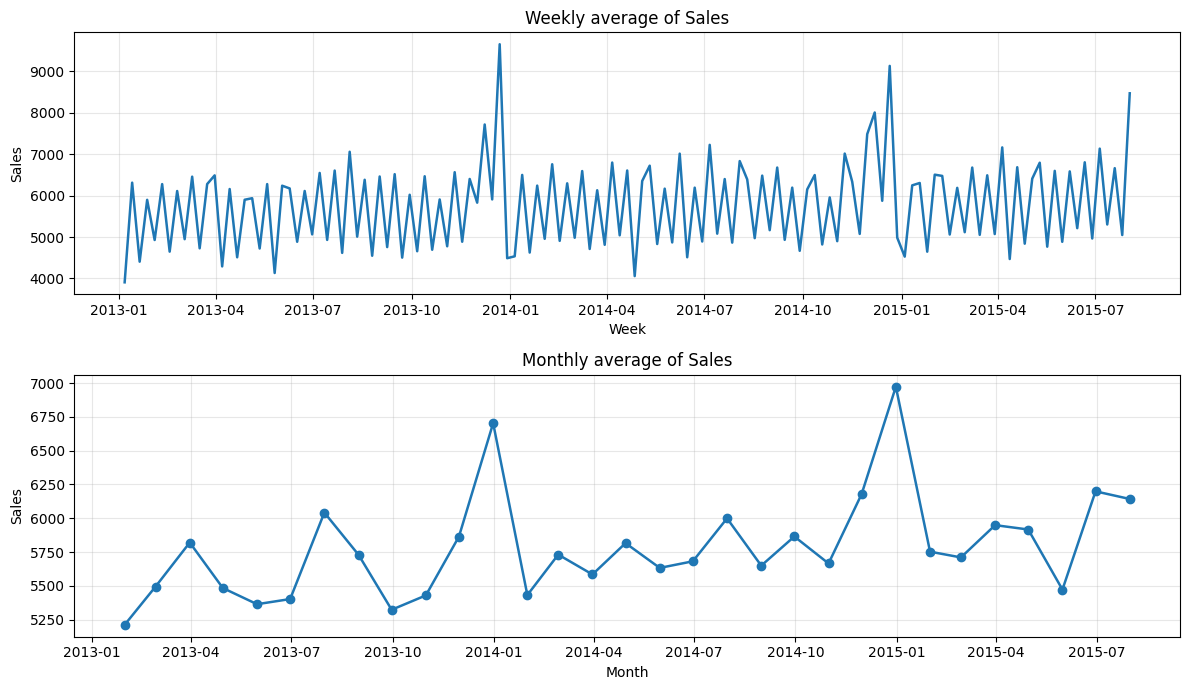

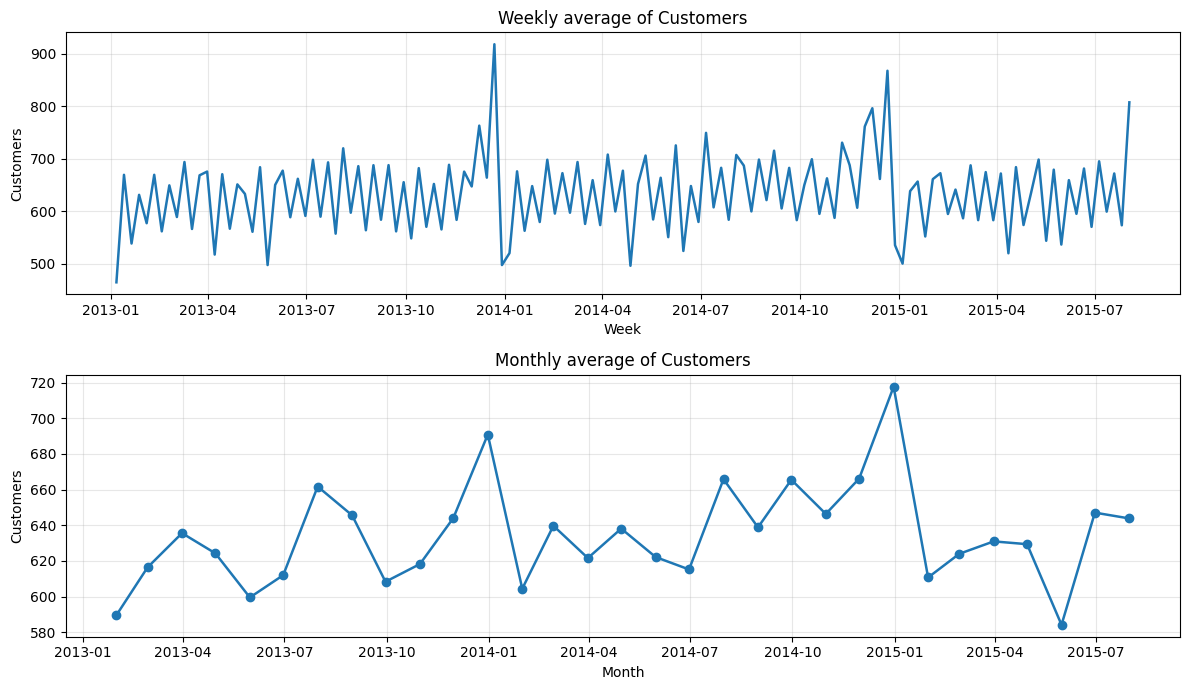

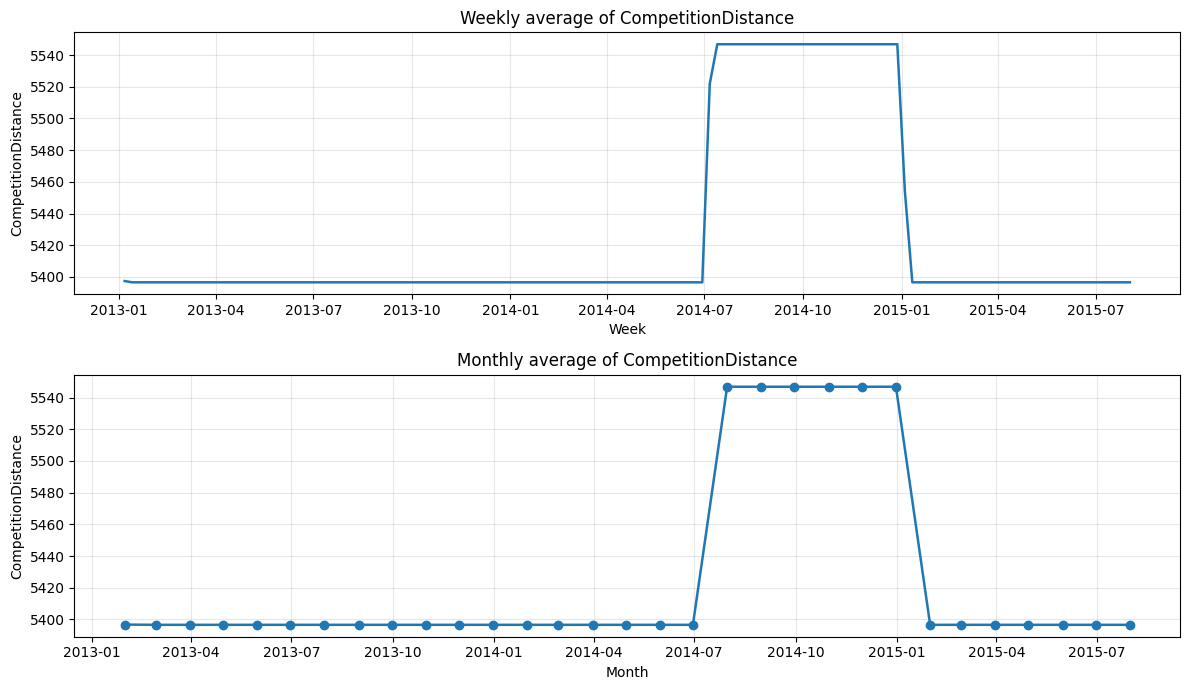

In [10]:
numeric_columns = list(train.select_dtypes(include=[np.number]).columns)

identifier_or_categorical_columns = [
    "Store",
    "DayOfWeek",
]

temporal_sequence_columns = [
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "year",
    "month",
    "day",
    "weekofyear",
    "quarter",
    "dayofyear",
    "days_since_start",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "competition_open_months",
]

def is_binary_column(series):
    values = set(series.dropna().unique())
    return len(values) > 0 and values.issubset({0, 1})


excluded_columns = set(identifier_or_categorical_columns + temporal_sequence_columns)

continuous_columns_to_plot = []
excluded_binary_columns = []

for column in numeric_columns:
    if column in excluded_columns:
        continue
    if train[column].nunique(dropna=True) <= 1:
        continue
    if is_binary_column(train[column]):
        excluded_binary_columns.append(column)
        continue
    continuous_columns_to_plot.append(column)

weekly_means = (
    train.set_index("Date")[continuous_columns_to_plot]
    .resample("W")
    .mean()
)

monthly_means = train.set_index("Date")[continuous_columns_to_plot].resample("ME").mean()

print("For training data")

print(f"Continuous variables plotted: {len(continuous_columns_to_plot)}")
print(continuous_columns_to_plot)
print("\nBinary variables excluded:")
print(excluded_binary_columns)
print("\nTemporal/categorical variables excluded:")
print(sorted(excluded_columns.intersection(numeric_columns)))

for column in continuous_columns_to_plot:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
    
    axes[0].plot(weekly_means.index, weekly_means[column], linewidth=1.8)
    axes[0].set_title(f"Weekly average of {column}")
    axes[0].set_xlabel("Week")
    axes[0].set_ylabel(column)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(monthly_means.index, monthly_means[column], marker="o", linewidth=1.8)
    axes[1].set_title(f"Monthly average of {column}")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel(column)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. Chronological Train / Validation Split

For time-series forecasting, validation must come after training in time. Here we use the most recent 42 days of `train.csv` as validation.

In [12]:
train = train.sort_values(["Store", "Date"]).reset_index(drop=True)
test = test.sort_values(["Date", "Store"]).reset_index(drop=True)
test1 = test.sort_values(["Store", "Date"]).reset_index(drop=True)

max_train_date = train["Date"].max()
validation_start = max_train_date - pd.Timedelta(days=VALIDATION_DAYS - 1)

train_prepared = train[train["Date"] < validation_start].copy()
validation_prepared = train[train["Date"] >= validation_start].copy()
test_prepared = test.copy()
test1_prepared = test1.copy()

print("train period:", train_prepared["Date"].min().date(), "to", train_prepared["Date"].max().date())
print("validation period:", validation_prepared["Date"].min().date(), "to", validation_prepared["Date"].max().date())
print("test period:", test_prepared["Date"].min().date(), "to", test_prepared["Date"].max().date())
print("Test which was ordered as store->Date", test1_prepared["Date"].min().date(), "to", test1_prepared["Date"].max().date())

print("train rows:", len(train_prepared))
print("validation rows:", len(validation_prepared))
print("test rows:", len(test_prepared))
print("test1 rows", len(test1_prepared))

train period: 2013-01-01 to 2015-06-19
validation period: 2015-06-20 to 2015-07-31
test period: 2015-08-01 to 2015-09-17
Test which was ordered as store->Date 2015-08-01 to 2015-09-17
train rows: 970379
validation rows: 46830
test rows: 41088
test1 rows 41088


## 9. Define Features for Later Modeling

These feature lists will be useful in the PyTorch notebook. We keep categorical and numeric columns separated because categorical variables can later be represented with embeddings, while numerical variables can be standardized before entering the neural network.

The selected features follow three rules:

1. They are available both in the historical training data and in the future test data.
2. They have a reasonable relationship with store sales.
3. They avoid data leakage, meaning they do not use information that would be unknown at prediction time.

### Target and Excluded Feature

- `Sales` is the target variable because the objective is to forecast daily store sales.
- `Customers` is excluded even though it is strongly related to sales, because it is not available in the test set. In a real forecasting problem, we would not know the future number of customers before predicting future sales.

### Store and Store-Type Features

- `Store`: identifies each store. Different stores can have very different typical sales levels, so the model should be able to learn store-specific behavior.
- `StoreType`: captures the format/type of the store, which may influence customer volume and sales patterns.
- `Assortment`: describes the product assortment level. Stores with different assortments may have different sales potential.

### Calendar and Seasonality Features

- `DayOfWeek`: sales often follow weekly patterns, for example weekdays versus weekends.
- `year`, `month`, `day`, `weekofyear`, `quarter`, `dayofyear`: these help the model learn seasonal effects and changes over the calendar year.
- `is_weekend`, `is_month_start`, `is_month_end`: these capture specific calendar situations that may affect shopping behavior.
- `days_since_start`: gives the model a simple long-term time trend.
- `dow_sin`, `dow_cos`, `month_sin`, `month_cos`: these represent weekly and yearly cycles smoothly. This is useful because time is circular: for example, December and January are close in the yearly cycle.

### Store Operation and Holiday Features

- `Open`: tells the model whether the store is open. If a store is closed, sales are usually zero.
- `StateHoliday`: captures public/state holidays, when stores may be closed or customer behavior may change.
- `SchoolHoliday`: captures school holiday periods, which may affect shopping behavior and local demand.

### Promotion Features

- `Promo`: captures whether a normal promotion is active on that date. Promotions usually have a direct effect on sales.
- `Promo2`, `Promo2SinceWeek`, `Promo2SinceYear`: describe whether the store participates in a longer-term promotion and when it started.
- `promo2_active`: converts the raw Promo2 information into a more useful feature indicating whether Promo2 is actually active for the store in the current month.

### Competition Features

- `CompetitionDistance`: nearby competitors can affect store demand, so distance to the closest competitor is relevant.
- `CompetitionOpenSinceMonth`, `CompetitionOpenSinceYear`: describe when the nearby competitor opened.
- `competition_open_months`: transforms the competition opening date into the number of months since the competitor opened, which is easier for the model to interpret than separate month/year columns.

In [13]:
target_column = "Sales"

leakage_columns_not_used = ["Customers"]

categorical_features = [
    "Store",
    "DayOfWeek",
    "StateHoliday",
    "StoreType",
    "Assortment",
]

numeric_features = [
    "Open",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "year",
    "month",
    "day",
    "weekofyear",
    "quarter",
    "dayofyear",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "days_since_start",
    "competition_open_months",
    "promo2_active",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

model_features = categorical_features + numeric_features

print("target:", target_column)
print("categorical features:", len(categorical_features))
print("numeric features:", len(numeric_features))
print("total model features:", len(model_features))
print("excluded leakage columns:", leakage_columns_not_used)

target: Sales
categorical features: 5
numeric features: 25
total model features: 30
excluded leakage columns: ['Customers']


## 9.1 Selected features

In [14]:
relevant_features = [
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "Open",
    "DayOfWeek",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "dow_sin", #dow and month are turned to sin and cos to makes them numerical while maintaining the circularity of the data.
    "dow_cos",
    "month_sin",
    "month_cos",
    "competition_open_months", #the duration in time of how much a competitor is open
    "promo2_active" #the relevant infos of all the promo2 stuff
]

print("Relevant features:")
print(relevant_features)

Relevant features:
['Promo', 'StateHoliday', 'SchoolHoliday', 'Open', 'DayOfWeek', 'StoreType', 'Assortment', 'CompetitionDistance', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'competition_open_months', 'promo2_active']


## 9.2 Correlation Matrix

Here we calculate the correlation between the selected `relevant_features` and the target variable `Sales`. Since some relevant features are categorical, such as `StateHoliday`, `StoreType`, and `Assortment`, we first transform them with one-hot encoding. The result is a correlation matrix that helps us understand which variables are more strongly related to sales.

This does not serve any realy porpouse, its just to help visualize how data might correlate with the target variable

Correlation with Sales, sorted by absolute value:


,correlation_with_sales
Open,0.678472
DayOfWeek,-0.462125
Promo,0.452345
dow_cos,-0.307547
StateHoliday_0,0.254216
StateHoliday_a,-0.203028
StoreType_b,0.139940
StateHoliday_b,-0.117497
dow_sin,0.101546
StateHoliday_c,-0.092618


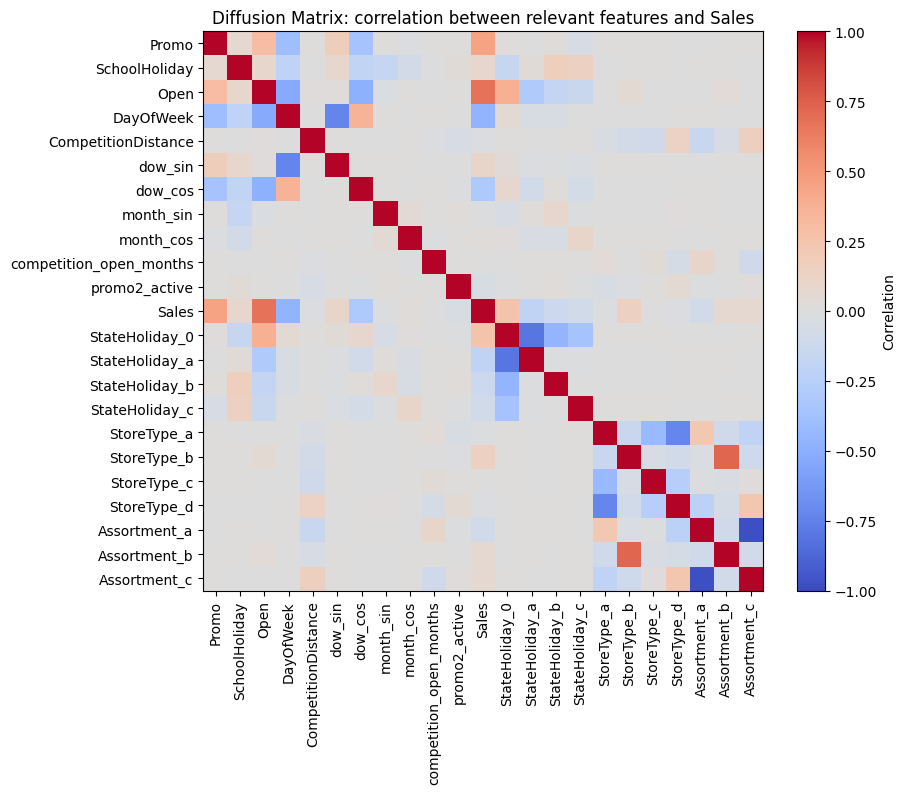

In [15]:
# Use all historical rows with known Sales for this exploratory analysis.
historical_prepared = pd.concat([train_prepared, validation_prepared], axis=0).copy()

# Keep only selected features that are actually present in the prepared dataset.
available_relevant_features = [
    column for column in relevant_features
    if column in historical_prepared.columns
]

missing_relevant_features = [
    column for column in relevant_features
    if column not in historical_prepared.columns
]

if missing_relevant_features:
    print("Relevant features not found and therefore excluded:")
    print(missing_relevant_features)

correlation_input = historical_prepared[available_relevant_features + [target_column]].copy()

# One-hot encode categorical features so they can be included in correlation analysis.
correlation_encoded = pd.get_dummies(correlation_input, drop_first=False)
correlation_matrix = correlation_encoded.corr(numeric_only=True)

sales_correlations = (
    correlation_matrix[target_column]
    .drop(target_column)
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

print("Correlation with Sales, sorted by absolute value:")
display(sales_correlations.to_frame("correlation_with_sales"))

plt.figure(figsize=(max(10, 0.45 * len(correlation_matrix.columns)), max(8, 0.35 * len(correlation_matrix.columns))))
im = plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Diffusion Matrix: correlation between relevant features and Sales")
plt.tight_layout()
plt.show()

## 10. Save Prepared Files

The next notebook/script can load these files directly instead of repeating all preparation steps.

In [16]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_prepared.to_csv(OUTPUT_DIR / "train_prepared.csv", index=False)
validation_prepared.to_csv(OUTPUT_DIR / "validation_prepared.csv", index=False)
test_prepared.to_csv(OUTPUT_DIR / "test_prepared.csv", index=False)
test1_prepared.to_csv(OUTPUT_DIR / "test1_prepared.csv", index=False)

data_summary = {
    "settings": {
        "use_sample": USE_SAMPLE,
        "sample_stores": SAMPLE_STORES if USE_SAMPLE else None,
        "min_date": MIN_DATE if USE_SAMPLE else None,
        "validation_days": VALIDATION_DAYS,
        "random_state": RANDOM_STATE,
    },
    "raw_shapes": {
        "train": list(RAW_TRAIN_SHAPE),
        "test": list(RAW_TEST_SHAPE),
        "test1": list(RAW_TEST_SHAPE),
        "store": list(RAW_STORE_SHAPE),
    },
    "prepared_shapes": {
        "train": list(train_prepared.shape),
        "validation": list(validation_prepared.shape),
        "test": list(test_prepared.shape),
        "test1": list(test1_prepared.shape)
    },
    "date_ranges": {
        "train": [str(train_prepared["Date"].min().date()), str(train_prepared["Date"].max().date())],
        "validation": [str(validation_prepared["Date"].min().date()), str(validation_prepared["Date"].max().date())],
        "test": [str(test_prepared["Date"].min().date()), str(test_prepared["Date"].max().date())],
        "test1": [str(test1_prepared["Date"].min().date()), str(test1_prepared["Date"].max().date())]
    },
    "feature_lists": {
        "target": target_column,
        "categorical_features": categorical_features,
        "numeric_features": numeric_features,
        "model_features": model_features,
        "relevant_features": relevant_features,
        "leakage_columns_not_used": leakage_columns_not_used,
    },
}

with open(OUTPUT_DIR / "data_summary.json", "w", encoding="utf-8") as f:
    json.dump(data_summary, f, indent=2)

print("Saved prepared files in:", OUTPUT_DIR.resolve())
print("Files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)

Saved prepared files in: C:\Users\Vaibhav\Documents\IML\outputs\prepared_notebook
Files:
- data_summary.json
- part_02_supervised_task_summary.json
- test1_prepared.csv
- test_prepared.csv
- train_prepared.csv
- validation_prepared.csv


## 11. What We Have Prepared

Running this notebook will leave the user with:

- `train_prepared.csv`: historical rows before the validation window.
- `validation_prepared.csv`: the most recent historical rows, used to evaluate forecasting performance.
- `test_prepared.csv`: future rows where the final model will predict `Sales`.
- `data_summary.json`: useful metadata about the split and feature lists.